# Importing Libraries

In [126]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

# Load Dataset

In [127]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [128]:
df.sample(5, random_state = 42)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C


In [129]:
print("Rows and Columns:")

df.shape

Rows and Columns:


(891, 12)

In [130]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [132]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [133]:
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


# Missing Value Analysis

In [134]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [135]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]

,0
Age,19.865320
Cabin,77.104377
Embarked,0.224467


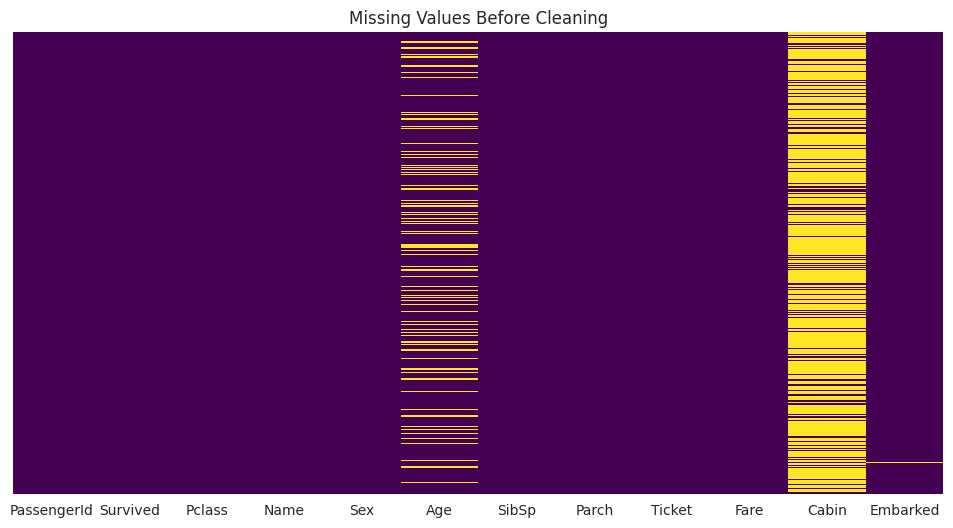

In [136]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis'
)

plt.title("Missing Values Before Cleaning")

plt.show()

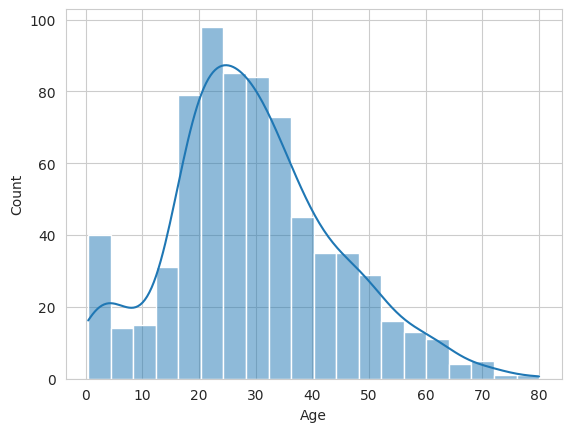

In [137]:
sns.histplot(df["Age"], kde=True)
plt.show()

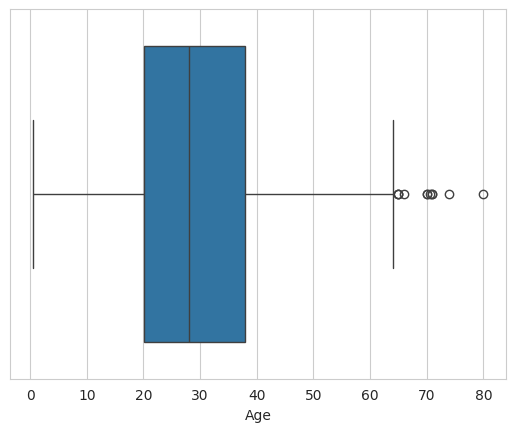

In [138]:
sns.boxplot(x=df["Age"])
plt.show()

In [139]:
print("Mean:", df["Age"].mean())
print("Median:", df["Age"].median())

Mean: 29.69911764705882
Median: 28.0


In [140]:
df['Age'] = df['Age'].fillna(
    df['Age'].median()
)

df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

df.drop(
    columns='Cabin',
    inplace=True
)

In [141]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


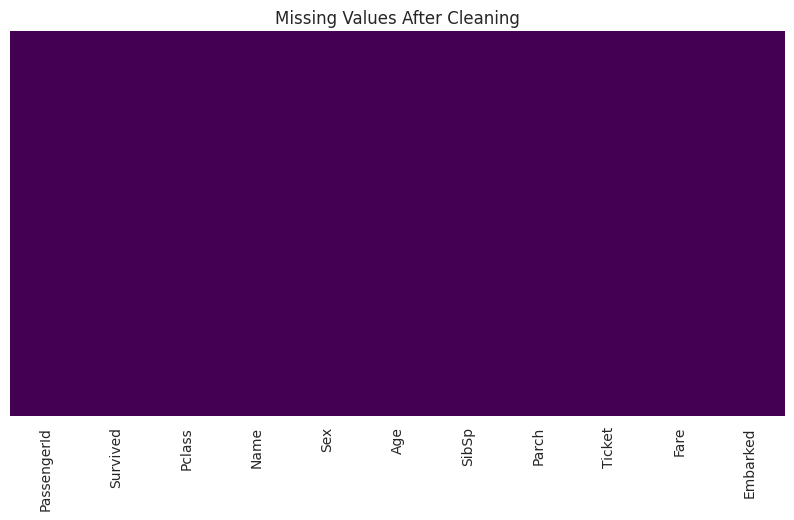

In [142]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis'
)

plt.title("Missing Values After Cleaning")

plt.show()

# Duplicate Records Analysis

In [143]:
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [144]:
df.drop_duplicates(inplace=True)

In [145]:
print("Remaining Duplicates:", df.duplicated().sum())

Remaining Duplicates: 0


# Data Type Analysis

In [146]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [147]:
df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


# Outlier Detection

In [148]:
numerical_columns = df.select_dtypes(include=np.number).columns

numerical_columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

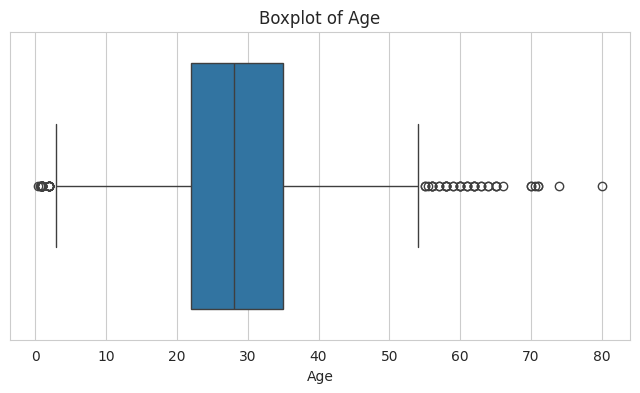

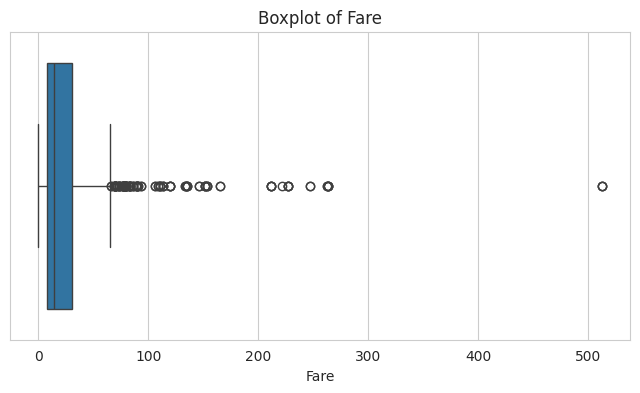

In [149]:
for col in ['Age','Fare']:

    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

    plt.show()

In [150]:
Q1 = df['Fare'].quantile(0.25)

Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -26.724
Upper Bound: 65.6344


In [151]:
df = df[
    (df['Fare'] >= lower_bound)
    &
    (df['Fare'] <= upper_bound)
]

In [152]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

upper_bound_new = Q3 + 1.5 * IQR

print(upper_bound_new)

53.1563


In [153]:
df[df['Fare'] > upper_bound_new]['Fare']

,Fare
54,61.9792
74,56.4958
92,61.1750
97,63.3583
155,61.3792
166,55.0000
169,56.4958
309,56.9292
329,57.9792
356,55.0000


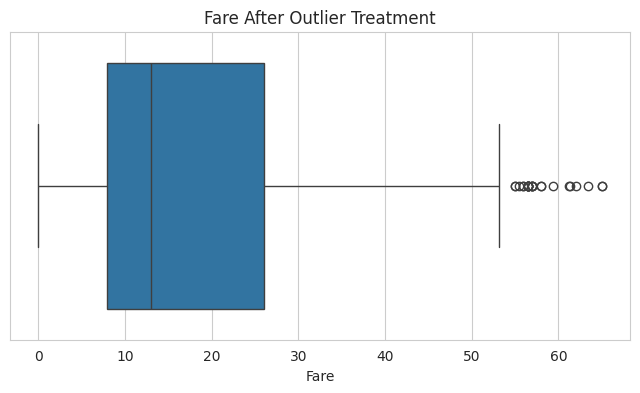

In [154]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['Fare']
)

plt.title(
    "Fare After Outlier Treatment"
)

plt.show()

# Feature Engineering

In [155]:
df['FamilySize'] = (df['SibSp'] + df['Parch'] + 1)

In [156]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [157]:
df[['FamilySize','IsAlone']].head()

,FamilySize,IsAlone
0,2,0
2,1,1
3,2,0
4,1,1
5,1,1


# Encoding Categorical Variables

In [158]:
encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(df['Sex'])
df['Embarked'] = encoder.fit_transform(df['Embarked'])

In [159]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,2,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,2,0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,2,1,1
5,6,0,3,"Moran, Mr. James",1,28.0,0,0,330877,8.4583,1,1,1


# Feature Scaling

In [160]:
scaler = StandardScaler()

df[['Age','Fare']] = scaler.fit_transform(df[['Age','Fare']])

In [161]:
df[['Age','Fare']].head()

,Age,Fare
0,-0.528321,-0.779117
2,-0.215182,-0.729373
3,0.489381,2.599828
4,0.489381,-0.720161
5,-0.058613,-0.690071


# Data Visualization

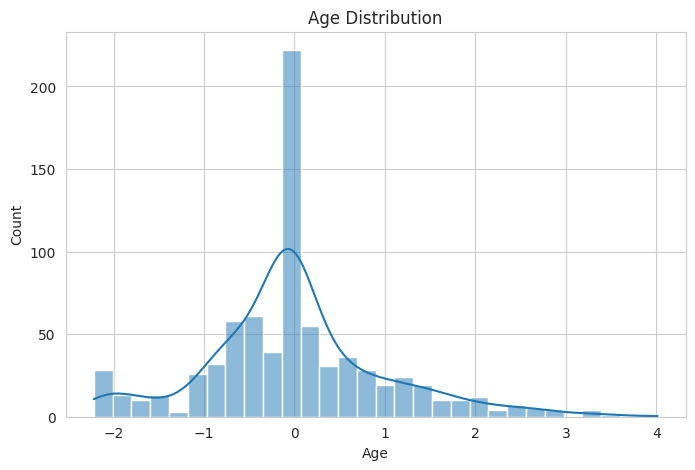

In [162]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title(
    "Age Distribution"
)

plt.show()

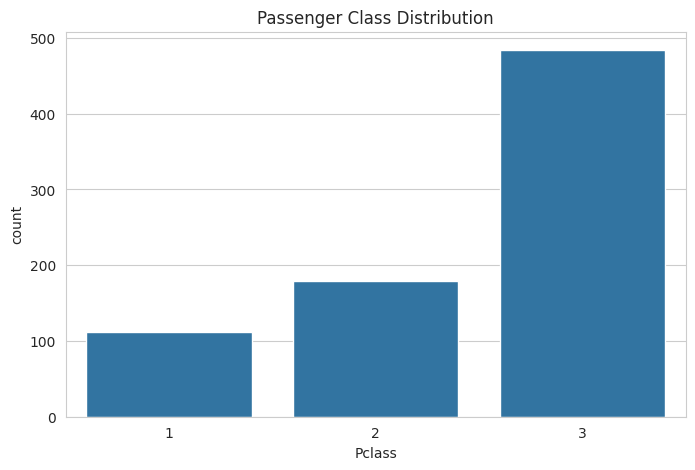

In [163]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Pclass',
    data=df
)

plt.title(
    "Passenger Class Distribution"
)

plt.show()

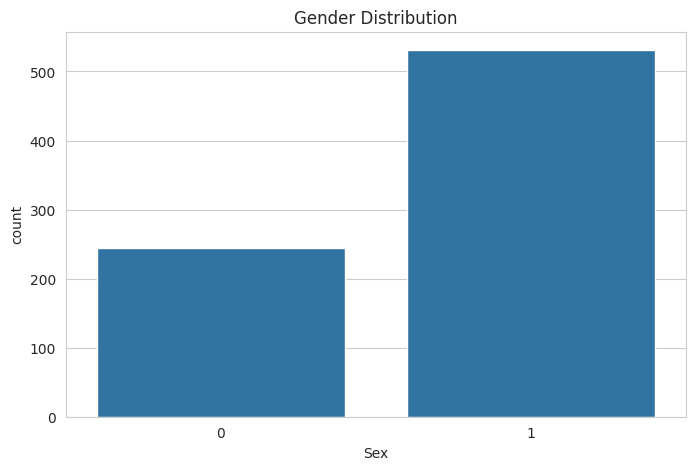

In [164]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sex',
    data=df
)

plt.title(
    "Gender Distribution"
)

plt.show()

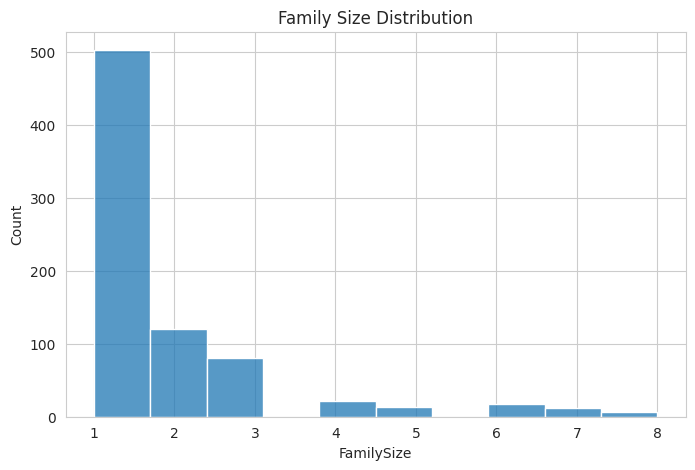

In [165]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['FamilySize'],
    bins=10
)

plt.title(
    "Family Size Distribution"
)

plt.show()

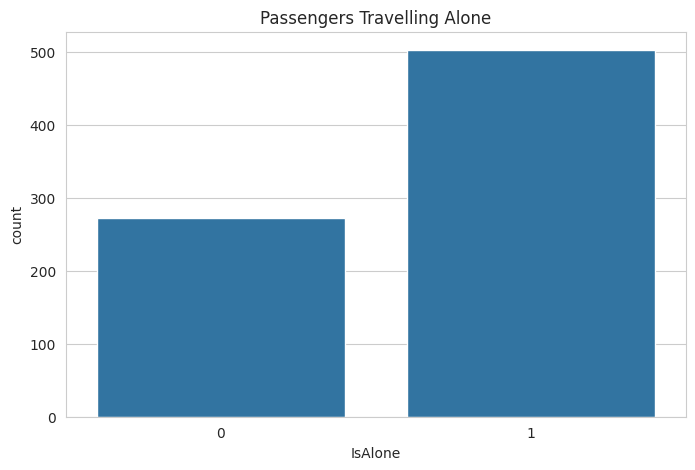

In [166]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='IsAlone',
    data=df
)

plt.title(
    "Passengers Travelling Alone"
)

plt.show()

In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  775 non-null    int64  
 1   Survived     775 non-null    int64  
 2   Pclass       775 non-null    int64  
 3   Name         775 non-null    object 
 4   Sex          775 non-null    int64  
 5   Age          775 non-null    float64
 6   SibSp        775 non-null    int64  
 7   Parch        775 non-null    int64  
 8   Ticket       775 non-null    object 
 9   Fare         775 non-null    float64
 10  Embarked     775 non-null    int64  
 11  FamilySize   775 non-null    int64  
 12  IsAlone      775 non-null    int64  
dtypes: float64(2), int64(9), object(2)
memory usage: 84.8+ KB


In [168]:
df.to_csv(
    "Titanic_Cleaned.csv",
    index=False
)

print(
    "Cleaned Dataset Saved Successfully"
)

Cleaned Dataset Saved Successfully


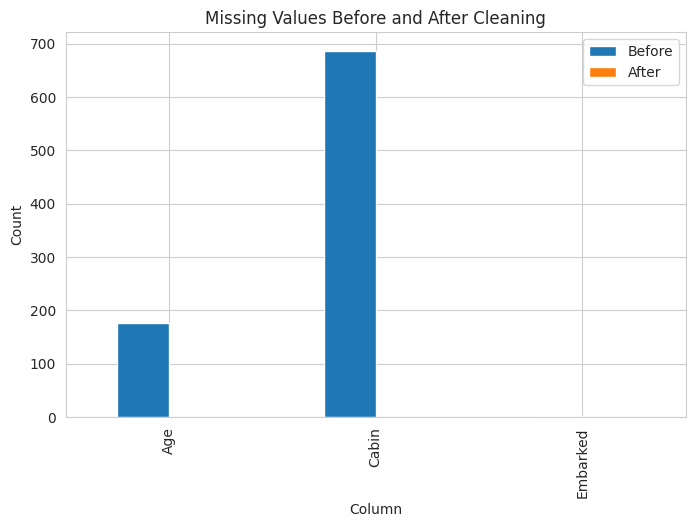

In [169]:
before_missing = [177, 687, 2]
after_missing = [0, 0, 0]

comparison = pd.DataFrame({
    'Column': ['Age','Cabin','Embarked'],
    'Before': before_missing,
    'After': after_missing
})

comparison.set_index('Column').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Missing Values Before and After Cleaning")
plt.ylabel("Count")

plt.show()